# To Dos
- Solve the forme issue regarding stats

# Trying to quantify advantage

Rather than giving the model a bunch of basic information (types, stats, known moves) and hoping that the model learns the stuff we already know (Fire > Grass > Water > Fire), let's tell the model the stuff that we already know.  But how do you feed in the type chart and whatnot into the model?  Seems hard.

Instead, let's bake all of our knowledge into a set of offensive and defensive stats (we'll call these "advantage" stats) that are derived for each specific battle.  Then, we'll replace the basic stats with these "advantage" stats.

We will start off by neglecting the movepool.  We could try to map each move to its category, type, and base power, but that could be a lot of work.  It's something to explore in the future.

## Damage Approximator
$\DeclareMathOperator{\dmg}{dmg}$
$\DeclareMathOperator{\adv}{adv}$
$\DeclareMathOperator{\ttko}{ttko}$
$\newcommand{\M}{\mathrm{M}}$
$\newcommand{\Atk}{\mathrm{Atk}}$
$\newcommand{\Defen}{\mathrm{Def}}$
$\newcommand{\SpAtk}{\mathrm{SpAtk}}$
$\newcommand{\SpDef}{\mathrm{SpDef}}$
The advantage stat starts with an approximation of damage. Given Pokemon $\M_1$ and $\M_2$ from Team 1 and Team 2, respectively, we approximate the <u>expected damage</u> $\dmg(\M_1,\M_2)$, a fraction of $H_2$ (the hit points of $\M_2$), that $\M_1$ does to $\M_2$ by selecting its best STAB move[^1]. Although different moves have different base *Power*s, we set $\mathrm{Power}=80$ for all moves for simplicity.

[^1]: Or a not-very-effective coverage move in the event that is better--this could be updated if we get data suggesting that in the event that a mon's best move is a coverage move, the coverage move is often neutral or better.

In addition, we define the <u>Effective</u> Attacking and Defending Stats $A_i$ and $D_i$ of $\M_i$ as follows: if $i \in \{1,2\}$, let $i'$ be the "complementary" element of $\{1,2\}$, so that $\{i,i'\} = \{1,2\}$. Then
$$ 
    A_i := \max\{\Atk_i, \SpAtk_i\} 
    \qquad\text{and}\qquad
    D_{i'} := \begin{cases}
        \Defen_{i}, & A_{i} = \Atk_i, \\
        \SpDef_{i}, & A_{i} = \SpAtk_{i},
    \end{cases}
$$
and *vice-versa* for $A_{i'}$ and $D_{i}$. Letting $L_i$ and $H_i$ be the Level and HP of $\M_i$, we set

$$
    \dmg(\M_{1},\M_{2}) := \frac{0.925}{H_2} \left(\frac{ 80\left(\tfrac{2}{5} L_{1} + 2\right) \cdot \frac{A_1}{D_2}}{50} + 2\right) \cdot E(\M_{1}, \M_{2}),
$$
where the <u>Effectiveness Multiplier</u>

$$ 
    E(\M_{1}, \M_{2}) := \max\left\{
        \frac{1}{2},\,\,
        1.5 \cdot \max_{T_1 \in \mathrm{Types}(\M_{1})} \mathrm{eff}(T_1, T_2)\mathrm{eff}(T_1, T_2'),
        \right\} 
$$

with $\text{eff}(T_1, T_2)$ being determined by the Type Chart, so that, e.g., 
$$ 
    \text{eff}(\text{water},\text{fire}) = 2, \qquad\text{and}\qquad \text{eff}(\text{fire},\text{water}) = \frac{1}{2}.
$$

Some notes:
- We allow $\dmg$ to exceed 1, as the amount by which it exceeds 1 may actually matter (think: reflect/light screen/aurora veil or resistance berries).
- The definition of $\dmg$ above uses a simplified version of the damage formula found [here](https://bulbapedia.bulbagarden.net/wiki/Damage#Generation_V_onward)
- For simplicity, we have set the base Powers of the moves used to be all be 80, which is the source of that factor in the formula.
- The factor $0.925$ is the mean of a $\mathrm{Unif}(0.85,1)$ random variable.

Notes for $E$:
- $E$ is meant to approximate the product of $\mathrm{STAB}$ and Type.
- The formula for $E$ inherently assumes that $M_1$ is only using STAB moves (this is the factor of $1.5$ present there); this could be updated to account for coverage moves in a future iteration on this stat.
- The $\max\{\frac{1}{2}, \cdot\}$ in $E(\M_1,\M_2)$ is to prevent $E$ from having value 0. It is very rare (though it does happen) that $M_1$ will be unable to damage $M_2$. The factor of $\frac{1}{2}$ is used because that is a multiplier for a "not-very-effective" coverage move. This could be resolved by replacing the maximum over $T_1$ by a maximum over $M_1$'s move types.

More Notes:
- Damage or speed-boosting items are not be accounted for. This could be resolved in an ad-hoc way by checking for common boosting items (choice items, life orb), or resolved in a systemic way using the Smogon damage calculator to replace the offensive advantage stat.
- Damage/stat-modifying abilities like Levitate, Thick Fat, or Sword of Ruin are not accounted for. This could 'only' be resolved by using the Smogon damage calculator to replace this offensive advantage stat.
- Type chart modifying moves like Freeze-Dry are not accounted for.

## Advantage

The only (relevant) thing that doesn't go into the damage approximator is speed. Speed is difficult to incorporate into advantage. There are a few reasons for this:
  1. The only important feature of speed differential (meaning $S_{1} - S_{2}$) is its sign; magnitude is meaningless here, so multiplying $\dmg$ by speed differential would be a bad idea.
  2. The impact of speed differential can be large or small.  If you consider a hypothetical Weavile versus Iron Boulder matchup, each has a super-effective STAB on the other (meaning it has a type-multiplier equal to 3)!  In that situation, Weavile has the advantage because it goes first.  However, if you consider a Weavile versus Swampert matchup (where each has a type-multiplier of 1.5), the Swampert has the advantage in spite of its speed disadvantage due to its overall bulk.  My initial thought is that speed matters a lot when both pokemon are doing about the same amount of damage to one another, but doesn't matter very much when the pokemon are doing very different amounts of damage.  So 'having a speed advantage' should not correspond to a constant factor.

Also worth noting is that advantage depends not just on how much damage you're doing to your opponent, but how much damage your opponent is doing to you!

$\DeclareMathOperator{\Dttko}{\Delta_{\ttko{}}}$
$\newcommand{\Mon}{\mathrm{Mon}}$
Maybe try computing 'turns to KO' for each mon and look at differential.  Let's set
$$
    \ttko(\M_{1},\M_{2}) = \left\lceil \frac{1}{\dmg(\M_{1},\M_{2})} \right\rceil
$$
So we get something like
$$ 
    \Delta_{\ttko{}}(\M_{1},\M_{2}) = \ttko(\M_1,\M_2) - \ttko(\M_1,\M_2).
$$

Here, bigger is better for $\M_{1}$.

Properties that I want for $\adv$:
- There should be a nice relationship between $\adv(\M_1,\M_2)$ and $\adv(\M_2,\M_1)$, ($a+b=1$ with $0 < a,b < 1$?  $ab = 1$?)
- If $\Dttko{} \approx 0$ and both $\ttko \approx 1$, the faster Mon should have a large $\adv$, as the faster Mon just OHKOs the slower Mon with no cost.
- If $\Dttko{} \approx 0$ but both $\ttko \gg 1$, then the faster Mon should one have a small advantage, as here the faster Mon eventually KOs the slower Mon, but both inflict comparable damage on each other.
- If $\Dttko{} \gg 1$, the Mon with the smaller $\ttko$ should have a big advantage, as here one Mon clearly overpowers the other.

$\DeclareMathOperator{\dmgovo}{dmg_{tot}}$
$\DeclareMathOperator{\toko}{toko}$

So maybe $\adv$ should represent something like: expected total damage dealt to opponent in a 1v1 matchup? If we let $n$ denote the round number <u>in which the KO occurs</u>, then the faster Mon gets to go $n$ times and the slower Mon gets to go $n$ or $n-1$ times depending on who wins. 

Then

$$
    \toko(\M_{1},\M_{2}) = \min\Big\{\ttko(\M_{1},M_{2}), \ttko(\M_{2},\M_{1})\Big\}
$$

So

$$
\dmgovo(\M_{1},\M_{2}) =
\begin{cases}
    \dmg(\M_{1},\M_{2})\cdot \big({\toko(\M_{1},\M_{2}) - 1}\big)  &\text{if $S_1 < S_2$ and $\M_2$ KOs $\M_1$},\\
    \dmg(\M_{1},\M_{2})\cdot \toko(\M_{1},\M_{2})         &\text{else.}
\end{cases}
$$

Then we can do something like set 
$$
    \adv(\M_{1},\M_{2}) := \dmgovo(\M_{1},\M_{2})
$$
or we can do something fancy and make it symmetric like 
$$
    \adv(\M_{1},M_{2}) := \dmgovo(\M_{1},\M_{2}) - \dmgovo(\M_{2},\M_{1}).
$$

Regardless, this should be enough to get started.

## Potential problems with advantage stats

Some pokemon are not good because of their stats.  Take Sableye for example.  It has atrocious stats, but can win a match on the strength of its ability, Prankster.  These advantage stats won't account for that.  (On the other hand, neither will training on 12-dimensional info above.)

Other pokemon don't rely on their offensive stats for damage (think Toxapex).

Yet more pokemon rely heavily on priority moves.

# Testing

In order to test the FullPokemon class, we need:

Testing Effectiveness multiplier $E(\M_1,\M_2)$:
  - $\M_{1}$ has a $4\times$ effective STAB ($\M_{1}$ = Weavile, $\M_{2}$ = Salamence)
  - $\M_{1}$ has a $2\times$ effective STAB ($\M_{1}$ = Weavile, $\M_{2}$ = Haxorus)
  - $\M_{1}$'s best STAB is neutral ($1\times$) ($\M_{1}$ = Weavile, $\M_{2}$ = Corviknight)
  - $\M_{1}$'s best STAB is $\frac{1}{2}\times$ effective ($\M_{1}$ = Weavile, $\M_{2}$ = Chien-Pao)
  - $\M_{1}$'s best STAB is $\frac{1}{4}\times$ effective ($\M_{1}$ = Conkeldurr, $\M_{2}$ = Fezandipiti)
  - $\M_{1}$'s best STAB is $0\times$ effective ($\M_{1}$ = Banette, $\M_{2}$ = Wigglytuff)  

Testing $\dmg$:
  - already tested manually by comparing physical and special attackers on the calcs at calc.pokemonshowdown.com

Testing $\dmgovo$:
  - $\M_{1}$ is faster than $\M_{2}$ and KOs $\M_{2}$ ($\M_{1}$ = Weavile, $\M_{2}$ = Salamence)
  - $\M_{2}$ is faster than $\M_{1}$ and KOs $\M_{1}$ ($\M_{1}$ = Sinistcha?, $\M_{2}$ = Weavile)
  - $\M_{1}$ is faster than $\M_{2}$ yet is KOd by $\M_{2}$ ($\M_{1}$ = Weavile, $\M_{2}$ = Conkeldurr)
  - $\M_{2}$ is faster than $\M_{1}$ yet is KOd by $\M_{1}$ ($\M_{1}$ = Swampert, $\M_{2}$ = Corviknight?)
  - $\M_{1}$ and $\M_{2}$ have a speed tie ($\M_{1}$ = Lanturn, $\M_{2}$ = Toxtricity)

--------
# EDA
--------

## Frequency of appearance

In [53]:
import sys, os, json
import pandas as pd
from pathlib import Path

sys.path.insert(1,os.path.abspath('../..'))
from tools import battle as b

In [55]:
log_dir = Path("../../data/replays/gen9-randombattle")
log_dir2 = Path("../../data/replays/2_gen9-randombattle")

M_win = []
M_win_f = []
M_lose = []
M_lose_f = []

error_ids = []

for file in log_dir.iterdir():
    if file.name.endswith(".json"):
        try: 
            battle = b.Battle(file)
            pw = battle.winner.side
            pl = battle.loser.side
            M_win.extend(battle.teams[pw-1].items())
            M_win_f.extend(battle.teams_full[pw-1].items())
            M_lose.extend(battle.teams[pl-1].items())
            M_lose_f.extend(battle.teams_full[pl-1].items())
        except: 
            print(f"error with {file.stem}")
            error_ids.append(file.stem)
            continue

In [60]:
S

[('Abomasnow', {spec: Abomasnow, lvl: 84, hp/max: 287/287}),
 ('Klefki', {spec: Klefki, lvl: 84, hp/max: 233/233}),
 ('Ceruledge', {spec: Ceruledge, lvl: 78, hp/max: 245/245}),
 ('Chansey', {spec: Chansey, lvl: 85, hp/max: 564/564}),
 ('Hippowdon', {spec: Hippowdon, lvl: 82, hp/max: 311/311}),
 ('Clefable', {spec: Clefable, lvl: 83, hp/max: 293/293}),
 ('Regigigas', {spec: Regigigas, lvl: 84, hp/max: 322/322})]

In [59]:
M_win_f[:6]

[('Abomasnow',
  {'name': 'Abomasnow',
   'species': 'Abomasnow',
   'speciesId': 'abomasnow',
   'gender': 'F',
   'shiny': False,
   'level': 84,
   'moves': ['auroraveil', 'woodhammer', 'blizzard', 'earthquake'],
   'ability': 'Snow Warning',
   'evs': {'hp': 77, 'atk': 85, 'def': 85, 'spa': 85, 'spd': 85, 'spe': 85},
   'ivs': {'hp': 31, 'atk': 31, 'def': 31, 'spa': 31, 'spd': 31, 'spe': 31},
   'item': 'Light Clay',
   'teraType': 'Water',
   'role': 'Bulky Support',
   'bvs': {'hp': 90, 'atk': 92, 'def': 75, 'spa': 92, 'spd': 85, 'spe': 60},
   'stats': {'hp': 287,
    'atk': 203,
    'def': 174,
    'spa': 203,
    'spd': 191,
    'spe': 149},
   'types': ['Grass', 'Ice']}),
 ('Ceruledge',
  {'name': 'Ceruledge',
   'species': 'Ceruledge',
   'speciesId': 'ceruledge',
   'gender': 'F',
   'shiny': False,
   'level': 78,
   'moves': ['swordsdance', 'poltergeist', 'closecombat', 'bitterblade'],
   'ability': 'Weak Armor',
   'evs': {'hp': 85, 'atk': 85, 'def': 85, 'spa': 85, 'spd'

In [45]:
for file in log_dir2.iterdir():
    if file.name.endswith(".json"):
        try: 
            battle = b.Battle(file)
            pw = battle.winner.side
            pl = battle.loser.side
            M_win.extend(battle.teams[pw-1].keys())
            M_win_f.extend(battle.teams_full[pw-1].keys())
            M_lose.extend(battle.teams[pl-1].keys())
            M_lose_f.extend(battle.teams_full[pl-1].keys())
        except: 
            print(f"error with {file.stem}")
            error_ids.append(file.stem)
            continue

Could not parse turn 0, line: |switch|p1a: Solgaleo|Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 3, line: |-damage|p1a: Solgaleo|308/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 5, line: |-damage|p1a: Solgaleo|274/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-damage|p1a: Solgaleo|236/342 (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-heal|p1a: Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 8, line: |-damage|p1a: Solgaleo|0 fnt (id:gen9randombattle-2641541263)
Need to pass a nonempty Team object.
error with gen9randombattle-2641541263


In [51]:
M_seen = list(set(M_win_f))

In [40]:
Sw = pd.Series(M_win).value_counts().sort_index()
Sl = pd.Series(M_lose).value_counts().sort_index()
Swf = pd.Series(M_win_f).value_counts().sort_index()
Slf = pd.Series(M_lose_f).value_counts().sort_index()

In [41]:
(Sw-Swf).sort_values(ascending=False)

Zoroark       0
Clodsire     -8
Camerupt     -9
Hypno       -10
Wo-Chien    -11
             ..
Regidrago   -50
Kommo-o     -52
Oricorio    -62
Deoxys      -64
Arceus      -95
Name: count, Length: 420, dtype: int64

In [42]:
S_wl_rat = ((Sw-Sl)/(Sw+Sl)).sort_index()
S_wl_rat

Abomasnow   -0.009901
Alcremie    -0.112903
Alomomola   -0.067194
Altaria     -0.052632
Ambipom      0.010753
               ...   
Zapdos      -0.188940
Zarude      -0.142857
Zebstrika   -0.140562
Zekrom      -0.114583
Zoroark      0.017544
Name: count, Length: 420, dtype: float64

In [43]:
S_wl_rat.describe()

count    420.000000
mean      -0.059942
std        0.066795
min       -0.250000
25%       -0.104730
50%       -0.058074
75%       -0.012769
max        0.139241
Name: count, dtype: float64

In [52]:
ADV = [ [ b.FullPokemon.advantage(M_seen[M1],M_seen[M2]) for M2 in M_list ] for M1 in M_list ]
ADV_df = pd.DataFrame(ADV, index=M_list, columns=M_list)

TypeError: list indices must be integers or slices, not str

In [389]:
df_mean = ADV_df.mean(axis=1).sort_index()
df_mean

Abomasnow   -0.219509
Alcremie     0.236340
Alomomola   -0.027751
Altaria      0.108019
Ambipom     -0.287419
               ...   
Zapdos       0.287583
Zarude       0.053330
Zebstrika    0.049577
Zekrom      -0.022078
Zoroark     -0.244639
Length: 420, dtype: float64

In [395]:
df_mean.sort_values(ascending=False)[-10:]

Serperior   -0.490193
Dunsparce   -0.560580
Chansey     -0.595912
Pikachu     -0.622411
Palafin     -0.640447
Maushold    -0.773133
Terapagos   -0.805725
Smeargle    -0.955052
Ditto       -1.028949
Deoxys      -1.105449
dtype: float64

In [390]:
xx = pd.DataFrame({"Swlr" : S_wl_rat, "adv_mean" : df_mean})

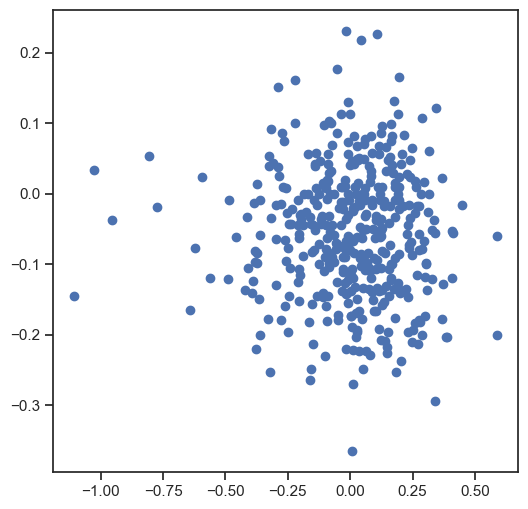

In [391]:
fig = plt.figure(figsize=(6,6))

plt.scatter(xx.adv_mean, xx.Swlr)

# New data

In [18]:
def pull_by_num(num):
    return b.Battle(f'../../data/replays/2_gen9-randombattle/gen9randombattle-{num}.json')

In [20]:
for btid in error_ids:
    pull_by_num(btid.removeprefix('gen9randombattle-'))

Could not parse turn 0, line: |switch|p1a: Solgaleo|Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 3, line: |-damage|p1a: Solgaleo|308/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 5, line: |-damage|p1a: Solgaleo|274/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-damage|p1a: Solgaleo|236/342 (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-heal|p1a: Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 8, line: |-damage|p1a: Solgaleo|0 fnt (id:gen9randombattle-2641541263)
Need to pass a nonempty Team object.


In [21]:
with open('../../data/replays/2_gen9-randombattle/gen9randombattle-2641541263.json','r') as file:
    btj = json.load(file)

In [22]:
print(btj['log'])

|j|☆cherry786
|j|☆kefka ffxiv
|inactive|Battle timer is ON: inactive players will automatically lose when time's up.
|t:|1782804075
|gametype|singles
|player|p1|cherry786|266|
|player|p2|kefka ffxiv|roxie|
|gen|9
|tier|[Gen 9] Random Battle
|rated|Tournament battle
|rule|Species Clause: Limit one of each Pokémon
|rule|HP Percentage Mod: HP is shown in percentages
|rule|Sleep Clause Mod: Limit one foe put to sleep
|rule|Illusion Level Mod: Illusion disguises the Pokémon's true level
|raw|<div class="infobox"><details class="readmore" open><summary><strong>3 custom rules:</strong></summary> maxteamsize=24, chimera1v1rule, adjustlevel=100</details></div>
|clearpoke
|poke|p1|Hypno, F|
|poke|p1|Palkia-Origin|
|poke|p1|Skarmory, M|
|poke|p1|Moltres|
|poke|p1|Slowbro-Galar, F|
|poke|p1|Volbeat, M|
|poke|p1|Grimmsnarl, M|
|poke|p1|Scovillain, F|
|poke|p1|Garchomp, M|
|poke|p1|Shiftry, M|
|poke|p1|Dodrio, F|
|poke|p1|Slaking, M|
|poke|p1|Wyrdeer, F|
|poke|p1|Kricketune, M|
|poke|p1|Solgaleo|
|p

In [16]:
b.Battle(path)

%%%%%%%%%%   Battle gen9randombattle-2641746190   %%%%%%%%%%
This was a battle between muddbud (pre-match rating 2100) and antho17### (pre-match rating 2188).

muddbud's lead pokemon was Zapdos-Galar, and their team (by `base`) was
 > Zapdos: {'species': 'Zapdos-Galar', 'level': 77, 'hp': 265}
 > Staraptor: {'species': 'Staraptor', 'level': 79, 'hp': 263}
 > Raikou: {'species': 'Raikou', 'level': 81, 'hp': 278}
 > Jolteon: {'species': 'Jolteon', 'level': 84, 'hp': 246}
 > Infernape: {'species': 'Infernape', 'level': 82, 'hp': 259}
 > Milotic: {'species': 'Milotic', 'level': 83, 'hp': 293}

antho17###'s lead pokemon was Eiscue, and their team (by `base`) was
 > Eiscue: {'species': 'Eiscue', 'level': 88, 'hp': 274}
 > Volcanion: {'species': 'Volcanion', 'level': 79, 'hp': 256}
 > Revavroom: {'species': 'Revavroom', 'level': 79, 'hp': 256}
 > Grafaiai: {'species': 'Grafaiai', 'level': 86, 'hp': 249}
 > Sceptile: {'species': 'Sceptile', 'level': 87, 'hp': 264}
 > Dudunsparce: {'species': '

In [23]:
log_dir = Path("../../data/replays/2_gen9-randombattle")

M_win2 = []
M_win_f2 = []
M_lose2 = []
M_lose_f2 = []

for file in log_dir.iterdir():
    if file.name.endswith(".json"):
        try: 
            battle = b.Battle(file)
            pw = battle.winner.side
            pl = battle.loser.side
            M_win2.extend(battle.teams[pw-1].keys())
            M_win_f2.extend(battle.teams_full[pw-1].keys())
            M_lose2.extend(battle.teams[pl-1].keys())
            M_lose_f2.extend(battle.teams_full[pl-1].keys())
        except: 
            print(f"error with {file.stem}")
            error_ids.append(file.stem)
            continue

Could not parse turn 0, line: |switch|p1a: Solgaleo|Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 3, line: |-damage|p1a: Solgaleo|308/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 5, line: |-damage|p1a: Solgaleo|274/342|[from] item: Life Orb (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-damage|p1a: Solgaleo|236/342 (id:gen9randombattle-2641541263)
Could not parse turn 7, line: |-heal|p1a: Solgaleo|342/342 (id:gen9randombattle-2641541263)
Could not parse turn 8, line: |-damage|p1a: Solgaleo|0 fnt (id:gen9randombattle-2641541263)
Need to pass a nonempty Team object.
error with gen9randombattle-2641541263


In [24]:
Sw2 = pd.Series(M_win2).value_counts().sort_index()
Sl2 = pd.Series(M_lose2).value_counts().sort_index()
Swf2 = pd.Series(M_win_f2).value_counts().sort_index()
Slf2 = pd.Series(M_lose_f2).value_counts().sort_index()

In [25]:
S_wl2_rat = ((Sw2-Sl2)/(Sw2+Sl2)).sort_index()
S_wl2_rat

Abomasnow   -0.117647
Alcremie    -0.213115
Alomomola   -0.046154
Altaria     -0.052632
Ambipom     -0.142857
               ...   
Zapdos      -0.177570
Zarude      -0.152941
Zebstrika   -0.017241
Zekrom      -0.227723
Zoroark      0.081081
Name: count, Length: 420, dtype: float64

In [30]:
S_wl_rat

Abomasnow    0.100000
Alcremie    -0.015873
Alomomola   -0.089431
Altaria     -0.052632
Ambipom      0.150685
               ...   
Zapdos      -0.200000
Zarude      -0.133333
Zebstrika   -0.248120
Zekrom       0.010989
Zoroark     -0.042735
Name: count, Length: 420, dtype: float64

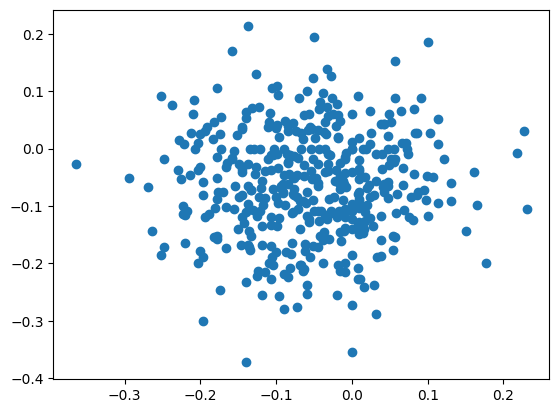

In [32]:
import matplotlib.pyplot as plt
plt.scatter(S_wl_rat, S_wl2_rat)

# Previous

In [10]:
test_pokemon = {mon : b.FullPokemon(desired_team_dict[mon]) for mon in desired_team_dict.keys()}

In [8]:
test_pokemon['Weavile'].stats

{'hp': 240, 'atk': 235, 'def': 148, 'spa': 117, 'spd': 180, 'spe': 243}

In [11]:
print("Now testing type_multiplier")

def E_test(M1, M2, val) : 
    return None if b.FullPokemon.type_multiplier(test_pokemon[M1],test_pokemon[M2]) == val else f"{M1} v. {M2} failed."

E_test('Weavile', 'Salamence', 6)
E_test('Weavile', 'Haxorus', 3)
E_test('Weavile', 'Corviknight', 1.5)
E_test('Weavile', 'Chien-Pao', 0.75)
E_test('Conkeldurr', 'Fezandipiti', 0.5)
E_test('Banette', 'Wigglytuff', 0.5)

print()
print("Now testing one_v_one_damage")

# ovo = [dmg_ovo(M1,M2), dmg_ovo(M2,M1)]
ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Weavile'],test_pokemon['Salamence'])
assert(ovo[0] >= 1 and ovo[1] == 0), "Weavile and Salamence failed"

ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Sinistcha'],test_pokemon['Weavile'])
assert(0 < ovo[0] < 1 and ovo[1] >= 1), "Sinistcha and Weavile failed"

ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Weavile'],test_pokemon['Conkeldurr'])
assert(0 < ovo[0] < 1 and ovo[1] >=1),"Weavile and Conkeldurr failed"

ovo = b.FullPokemon.one_v_one_damage(test_pokemon['Swampert'],test_pokemon['Corviknight'])
assert(ovo[0] >= 1 and 0 < ovo[1] < 1), "Swampert and Corviknight failed"

ovo = b.FullPokemon.one_v_one_damage(test_pokemon["Lanturn"],test_pokemon["Toxtricity"])
assert(ovo[0] >= 1 and 0.72 <= ovo[1] < 1), "Lanturn and Toxtricity failed"

Now testing type_multiplier

Now testing one_v_one_damage


## Examples

In [12]:
id = "2631906096"
with open("../data/replays/gen9-randombattle/gen9randombattle-" + id + ".json","r") as battle_json:
    data = json.load(battle_json)

team1 = [b.FullPokemon(data["teams_full"][0][key]) for key in data["teams_full"][0].keys()]
team2 = [b.FullPokemon(data["teams_full"][1][key]) for key in data["teams_full"][1].keys()]

col_names = [f"adv_over_{mon2.name}" for mon2 in team2]
col_names.insert(0,"p1_mon")

rows = []
for i,mon1 in enumerate(team1):
    rows.append([b.FullPokemon.advantage(mon1,mon2) for mon2 in team2])
    rows[i].insert(0,mon1.name)
df = pd.DataFrame(rows,columns=col_names)

adv_matrix = [[b.FullPokemon.advantage(mon1,mon2) for mon2 in team2] for mon1 in team1]

sum(sum(adv_matrix[i]) for i in range(len(adv_matrix)))

4.815082462271961

In [72]:
import numpy as np
import numpy.linalg as linalg
import scipy.linalg as alg

# team1 attacking team2
X = np.array([
    [np.round(b.FullPokemon.advantage(M1,M2),2) for M2 in team2] for M1 in team1
])

# team2 attacking team1
Y = np.array([
    [np.round(b.FullPokemon.advantage(M2,M1),2) for M1 in team1] for M2 in team2
])

In [ ]:
X

In [ ]:
Y

In [ ]:
df

## EDA

In [4]:
import sys
import os
import json
import pandas as pd
import matplotlib as plt
import seaborn as sns
from pathlib import Path
sys.path.insert(1,os.path.abspath('../..'))
from tools import battle as b
log_dir = Path("../../data/replays/gen9-randombattle")
stat_names = ['hp','atk','def','spa','spd','spe']

In [141]:
rows = []
col_names = ['battle_id','p1_wins','elo_diff']
for i in range(6):
    for j in range(6):
        col_names.append(f"adv_M{i+1}M'{j+1}")
# for i in range(6):
#     for j in range(6):
#         col_names.append(f"adv_M'{i+1}M{j+1}")
        
for file in log_dir.iterdir():
    if file.name.endswith('.json'):
        battle = b.Battle(file)
        if not (battle.custom_ruleQ) and not (battle.end_time - battle.start_time < 60): # throw out battles with custom rules and those that last less than 60 seconds
            with file.open() as battle_json:
                battle_data = json.load(battle_json)
            
            rows.append([battle_data["id"].removeprefix('gen9randombattle-'), int(battle.winner.name == battle.p1.name), battle.p1.elo0-battle.p2.elo0])
            
            team1 = [b.FullPokemon(battle_data["teams_full"][0][mon]) for mon in battle_data["teams_full"][0].keys()]
            team2 = [b.FullPokemon(battle_data["teams_full"][1][mon]) for mon in battle_data["teams_full"][1].keys()]
            
            for i in range(6):
                for j in range(6):
                    rows[-1].append(b.FullPokemon.advantage(team1[i],team2[j]))
            # for i in range(6):
            #     for j in range(6):
            #         rows[-1].append(b.FullPokemon.advantage(team2[i],team1[j]))

df = pd.DataFrame(rows,columns=col_names)

In [ ]:
df.head(10)

In [209]:
import numpy.linalg as NLA
import scipy.linalg as SLA

df_temp = df[df.columns[3:39]]
# df_2t1 = df[df.columns[39:]]

def row_det(row):
    return SLA.det(np.array(row).reshape(-1,6))
    
df_mat = df_temp.apply(sum, axis=1)

In [155]:
ss = StandardScaler()
ss.fit(df_mat.to_frame())

array([0.1886194])

In [217]:
X = df_mat
y = df['p1_wins']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [228]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('LR', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

LR = LogisticRegression()
LR.fit(X_train.to_frame(), y_train)
LR.score(X_test.to_frame(), y_test)
# pipe.fit(X_train.to_frame(), y_train)

0.5203111495246326

# Random Forest things

In [148]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, AdaBoostClassifier, 
    RandomForestClassifier, ExtraTreesClassifier
)

from sklearn import metrics
from sklearn import datasets, svm
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_validate, cross_val_score, train_test_split

from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

In [89]:
N_max = 4500

X = df.loc[df.index < N_max].drop(['battle_id', 'p1_wins', 'elo_diff'], axis=1)
y = df.loc[df.index < N_max].p1_wins

In [19]:
RF_acc, DT_acc = [], []

for i in range(25):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        stratify=y
    )
    
    DT = DecisionTreeClassifier(max_depth=50)
    DT.fit(X_train, y_train)
    DT_acc.append(DT.score(X_test, y_test))
    
    RF = RandomForestClassifier()
    RF.fit(X_train, y_train)
    RF_acc.append(RF.score(X_test, y_test))

print(f"RF mean accuracy: {np.mean(RF_acc):.3f} ± {np.std(RF_acc):.3f}")
print(f"DT mean accuracy: {np.mean(DT_acc):.3f} ± {np.std(DT_acc):.3f}")

RF mean accuracy: 0.492 ± 0.018
DT mean accuracy: 0.505 ± 0.028


In [ ]:
models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    ExtraTreesClassifier(),
    svm.SVC(kernel='linear', C=1),
    # svm.SVC(kernel='rbf', C=1),
    AdaBoostClassifier(n_estimators=50),
    XGBClassifier(n_estimators=50, max_depth=4, objective='binary:logistic'),
    LogisticRegression()
]

acc_scores = {}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

for model in models:
    _scores = cross_val_score(model, X_train, y_train, cv=5)
    # acc_scores[type(model).__name__] = _scores
    acc_scores[type(model).__name__] = {"mean": np.mean(_scores), "std": np.std(_scores)}

df_scores = pd.DataFrame(acc_scores).T
df_scores = df_scores.map(lambda x : np.round(x,3)).sort_values('mean', ascending=False)
df_scores

## `sklearn` examples

In [30]:
X, y = datasets.load_iris(return_X_y=True)
X.shape, y.shape

((150, 4), (150,))

In [27]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score

clf = svm.SVC(kernel='linear', C=1, random_state=0)

scores = cross_validate(clf, X, y, cv=5, scoring=['precision_macro', 'recall_macro'])
print(sorted(scores.keys()))

['fit_time', 'score_time', 'test_precision_macro', 'test_recall_macro']


* `cross_validate` and `cross_validate_score` do largely the same thing; the former returns additional info about fitting/scoring times, and can score multiple scoring metrics. The latter can only take one metric at a time, and returns only the array of scores
* If `scoring` is left blank, then simple 'accuracy' is used for the score. In particular `<model>.score(X,y)` is used.

In [28]:
# used for a single `scoring` method, and only returns the scores
scores = cross_val_score(
    clf, X, y, cv=5, scoring='precision_macro')
scores

array([0.51241683, 0.5425511 , 0.54288368, 0.5205446 , 0.48409091])

In [31]:
X = df.loc[df.index < 2500].drop(['battle_id', 'p1_wins', 'elo_diff'], axis=1)
y = df.loc[df.index < 2500].p1_wins

In [149]:
DT.fit(X_train, y_train)
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

## adaboost

In [57]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=.2)
# create model instance

X, y = load_iris(return_X_y=True)
# models = [dtc, rfc, etc, svc_l, svc_r, abc, xgb]

In [87]:
models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    ExtraTreesClassifier(),
    # svm.SVC(kernel='linear', C=1),
    svm.SVC(kernel='rbf', C=1),
    AdaBoostClassifier(n_estimators=100),
    XGBClassifier(n_estimators=10, max_depth=2, learning_rate=1, objective='binary:logistic'),
    LogisticRegression()
]

acc_scores = {}

for model in models:
    _scores = cross_val_score(model, X, y, cv=5)
    # acc_scores[type(model).__name__] = _scores
    acc_scores[type(model).__name__] = {"mean": np.mean(_scores), "std": np.std(_scores)}

df_scores = pd.DataFrame(acc_scores).T
df_scores = df_scores.map(lambda x : np.round(x,3)).sort_values('mean', ascending=False)
df_scores

/opt/homebrew/Caskroom/miniforge/base/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,mean,std
LogisticRegression,0.973,0.025
SVC,0.967,0.021
DecisionTreeClassifier,0.960,0.033
RandomForestClassifier,0.960,0.025
AdaBoostClassifier,0.953,0.034
XGBClassifier,0.953,0.016
ExtraTreesClassifier,0.947,0.040


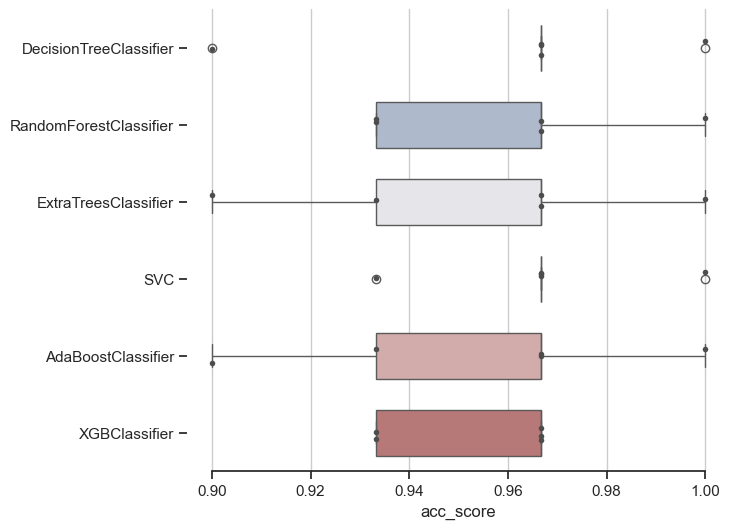

In [80]:
df3=df_scores.melt(var_name='model', value_name='acc_score')

f, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
    df3, 
    x="acc_score", 
    y="model", 
    hue="model",
    # whis=[0, 100], 
    width=.6, 
    palette="vlag"
)

# Add in points to show each observation
sns.stripplot(
    df3, 
    x="acc_score", 
    y="model", 
    size=4, 
    color=".3"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)

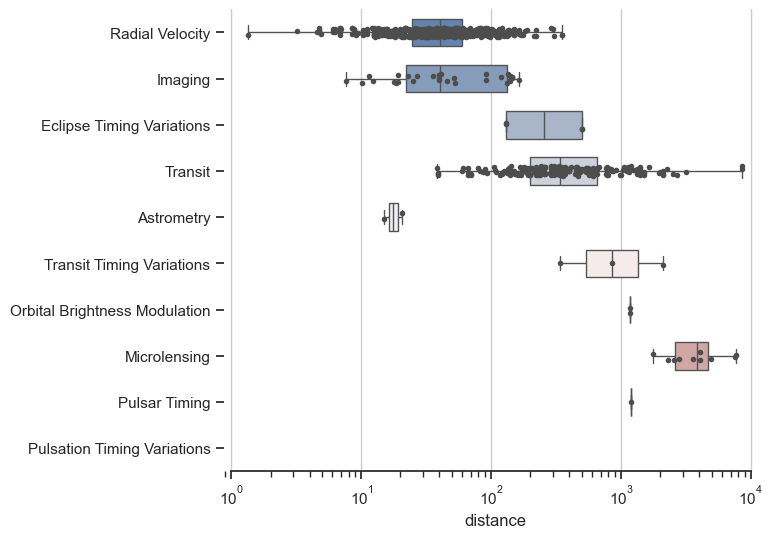

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
planets = sns.load_dataset("planets")
# Plot the orbital period with horizontal boxes
sns.boxplot(
    df_scores, x=", y="method", hue="method",
    whis=[0, 100], width=.6, palette="vlag"
)

# Add in points to show each observation
sns.stripplot(planets, x="distance", y="method", size=4, color=".3")

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)